<a href="https://www.kaggle.com/code/daniilkrizhanovskyi/v5-drift-buster?scriptVersionId=287862481" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Diabetes Prediction Challenge (Playground Series S5E12) — Deep EDA + Robust Modeling

**Goal:** predict the probability of `diagnosed_diabetes` for each `id` in the test set.  
**Metric:** ROC AUC (area under the ROC curve).

This notebook focuses on two things:

1. **Understanding the data** (train/test structure, feature meaning, distributions, and train↔test drift)
2. **A strong, reproducible baseline** that is GPU-friendly (P100) while staying stable on CPU.

> Note: this Playground dataset is synthetic (generated to resemble a real-world tabular dataset), so you should expect some distribution quirks.


## 0. Environment & Reproducibility


In [1]:
import os
import gc
import random
import warnings
import subprocess
from dataclasses import dataclass

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")

SEED = 42
def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

print("Python:", __import__("sys").version.split()[0])
print("pandas:", pd.__version__)
print("numpy :", np.__version__)

# GPU check (Kaggle P100 should show up here)
try:
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=name,memory.total,driver_version", "--format=csv,noheader"],
        text=True
    )
    print("\nGPU detected via nvidia-smi:")
    print(out.strip())
    HAS_GPU = True
except Exception as e:
    print("\nNo GPU detected via nvidia-smi:", repr(e))
    HAS_GPU = False


Python: 3.11.13
pandas: 2.2.3
numpy : 1.26.4

GPU detected via nvidia-smi:
Tesla P100-PCIE-16GB, 16384 MiB, 570.172.08


## 1. Load Data (train / test / sample_submission)

Kaggle path detection:
- If running on Kaggle, datasets are under `/kaggle/input/...`
- Otherwise, you can point `DATA_DIR` to your local folder


In [2]:
# ---- Path handling ----
DEFAULT_KAGGLE_DIR = "/kaggle/input/playground-series-s5e12"
DATA_DIR = DEFAULT_KAGGLE_DIR if os.path.exists(DEFAULT_KAGGLE_DIR) else "."

train_path = os.path.join(DATA_DIR, "train.csv")
test_path  = os.path.join(DATA_DIR, "test.csv")
sub_path   = os.path.join(DATA_DIR, "sample_submission.csv")

print("DATA_DIR:", DATA_DIR)
print("train_path:", train_path)
print("test_path :", test_path)
print("sub_path  :", sub_path)

train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)
sub   = pd.read_csv(sub_path)

print("\nShapes:")
print("train:", train.shape)
print("test :", test.shape)
print("sub  :", sub.shape)

display(train.head(3))
display(test.head(3))
display(sub.head(3))


DATA_DIR: /kaggle/input/playground-series-s5e12
train_path: /kaggle/input/playground-series-s5e12/train.csv
test_path : /kaggle/input/playground-series-s5e12/test.csv
sub_path  : /kaggle/input/playground-series-s5e12/sample_submission.csv

Shapes:
train: (700000, 26)
test : (300000, 25)
sub  : (300000, 2)


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0


,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history
0,700000,45,4,100,4.3,6.8,6.2,25.5,0.84,123,...,111,Female,White,Highschool,Middle,Former,Employed,0,0,0
1,700001,35,1,87,3.5,4.6,9.0,28.6,0.88,120,...,145,Female,White,Highschool,Middle,Never,Unemployed,0,0,0
2,700002,45,1,61,7.6,6.8,7.0,28.5,0.94,112,...,184,Male,White,Highschool,Low,Never,Employed,0,0,0


,id,diagnosed_diabetes
0,700000,0
1,700001,0
2,700002,0


## 2. Data Audit

We confirm:
- train contains the target `diagnosed_diabetes`
- test has identical feature columns (minus the target)
- no missing values / duplicates
- categorical columns and their cardinalities


In [3]:
TARGET = "diagnosed_diabetes"
ID_COL = "id"

assert TARGET in train.columns, f"Target '{TARGET}' not found in train."
assert TARGET not in test.columns, "Target column should not be in test."
assert ID_COL in train.columns and ID_COL in test.columns and ID_COL in sub.columns, "Missing id column."

# Column consistency
train_features = [c for c in train.columns if c != TARGET]
assert set(train_features) == set(test.columns), "Train features and test columns do not match."

# Missing values
missing_train = train.isna().sum().sort_values(ascending=False)
missing_test  = test.isna().sum().sort_values(ascending=False)

print("Missing values (train) - top:")
display(missing_train.head(10))
print("Missing values (test) - top:")
display(missing_test.head(10))

# Duplicates
dup_train = train.duplicated().sum()
dup_test  = test.duplicated().sum()
print(f"Duplicates: train={dup_train}, test={dup_test}")

# Identify categorical columns (object dtype)
cat_cols = [c for c in train_features if train[c].dtype == "object"]
num_cols = [c for c in train_features if c not in cat_cols + [ID_COL]]

print("\nCategorical columns:", cat_cols)
print("Numeric columns:", len(num_cols))

# Cardinalities
cat_card = {c: train[c].nunique() for c in cat_cols}
display(pd.Series(cat_card, name="nunique").sort_values(ascending=False))

# Target distribution
target_rate = train[TARGET].mean()
print(f"\nTarget positive rate: {target_rate:.4f} ({target_rate*100:.2f}%)")
display(train[TARGET].value_counts())


Missing values (train) - top:


id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
dtype: int64

Missing values (test) - top:


id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
dtype: int64

Duplicates: train=0, test=0

Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']
Numeric columns: 18


ethnicity            5
income_level         5
employment_status    4
education_level      4
gender               3
smoking_status       3
Name: nunique, dtype: int64


Target positive rate: 0.6233 (62.33%)


diagnosed_diabetes
1.0    436307
0.0    263693
Name: count, dtype: int64

## 3. Train vs Test Drift (Why you should care)

If train and test distributions differ, cross-validation may look strong but leaderboard performance can suffer.

We measure drift in three ways:

1. **Numerical KS statistic** (Kolmogorov–Smirnov) per feature  
2. **Categorical proportion deltas** per feature  
3. A **domain classifier** that tries to tell train vs test apart (AUC near 0.5 = no drift; higher = more drift)

All drift checks below are unsupervised (no label usage).


In [4]:
from scipy.stats import ks_2samp

def ks_drift_table(train_df: pd.DataFrame, test_df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    for c in cols:
        stat, p = ks_2samp(train_df[c].values, test_df[c].values)
        rows.append((c, float(stat), float(p)))
    out = pd.DataFrame(rows, columns=["feature", "ks_stat", "p_value"]).sort_values("ks_stat", ascending=False)
    return out

ks_table = ks_drift_table(train, test, num_cols)
display(ks_table.head(15))


,feature,ks_stat,p_value
2,physical_activity_minutes_per_week,0.105923,0.000000e+00
14,triglycerides,0.042122,0.000000e+00
11,cholesterol_total,0.027913,1.421473e-142
13,ldl_cholesterol,0.024113,1.664605e-106
10,heart_rate,0.010909,3.889975e-22
9,diastolic_bp,0.008071,2.601992e-12
7,waist_to_hip_ratio,0.007639,4.527338e-11
8,systolic_bp,0.006775,8.455463e-09
3,diet_score,0.006632,1.890305e-08
0,age,0.006420,6.025203e-08


In [5]:
# Categorical drift via frequency deltas (L1 distance over category proportions)
def categorical_drift(train_df: pd.DataFrame, test_df: pd.DataFrame, col: str) -> float:
    p = train_df[col].value_counts(normalize=True)
    q = test_df[col].value_counts(normalize=True)
    all_idx = p.index.union(q.index)
    p = p.reindex(all_idx, fill_value=0)
    q = q.reindex(all_idx, fill_value=0)
    return float(np.abs(p - q).sum())  # 0..2

cat_drift = [(c, categorical_drift(train, test, c), train[c].nunique()) for c in cat_cols]
cat_drift_df = pd.DataFrame(cat_drift, columns=["feature", "L1_prop_distance", "n_unique"]).sort_values("L1_prop_distance", ascending=False)
display(cat_drift_df)


,feature,L1_prop_distance,n_unique
2,education_level,0.043642,4
5,employment_status,0.021485,4
1,ethnicity,0.021445,5
0,gender,0.010500,3
3,income_level,0.004555,5
4,smoking_status,0.004285,3


In [6]:
# Domain classifier drift AUC (sampled for speed)
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

SAMPLE_PER_DOMAIN = 150_000  # adjust if you want; keep it <= ~200k for speed

train_s = train.sample(min(SAMPLE_PER_DOMAIN, len(train)), random_state=SEED)
test_s  = test.sample(min(SAMPLE_PER_DOMAIN, len(test)), random_state=SEED)

X_domain = pd.concat([train_s[train_features], test_s], axis=0, ignore_index=True)
y_domain = np.r_[np.zeros(len(train_s), dtype=int), np.ones(len(test_s), dtype=int)]

pre = ColumnTransformer([
    ("num", "passthrough", [c for c in train_features if c not in cat_cols + [ID_COL]]),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="drop")

domain_clf = LogisticRegression(max_iter=200, n_jobs=-1)

pipe = Pipeline([("pre", pre), ("clf", domain_clf)])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
aucs = []
for tr, va in skf.split(X_domain, y_domain):
    pipe.fit(X_domain.iloc[tr], y_domain[tr])
    pred = pipe.predict_proba(X_domain.iloc[va])[:, 1]
    aucs.append(roc_auc_score(y_domain[va], pred))

print(f"Domain AUC (train vs test separability): {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print("Interpretation: ~0.50 means minimal drift; higher means stronger train↔test shift.")


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Domain AUC (train vs test separability): 0.5571 ± 0.0012
Interpretation: ~0.50 means minimal drift; higher means stronger train↔test shift.


## 4. Exploratory Data Analysis (EDA)

We keep plots lightweight by sampling. The goal is to understand:

- which features have the strongest relationship with the target
- whether relationships are monotonic / nonlinear
- whether categories behave differently

Note: This is still synthetic data, so treat “medical realism” as approximate.


family_history_diabetes               0.212178
physical_activity_minutes_per_week   -0.169714
age                                   0.161527
systolic_bp                           0.107185
bmi                                   0.104439
ldl_cholesterol                       0.102136
triglycerides                         0.089281
cholesterol_total                     0.087559
waist_to_hip_ratio                    0.080013
hdl_cholesterol                      -0.051065
diet_score                           -0.050192
diastolic_bp                          0.035466
hypertension_history                  0.029697
heart_rate                            0.024167
cardiovascular_history                0.023337
Name: diagnosed_diabetes, dtype: float64

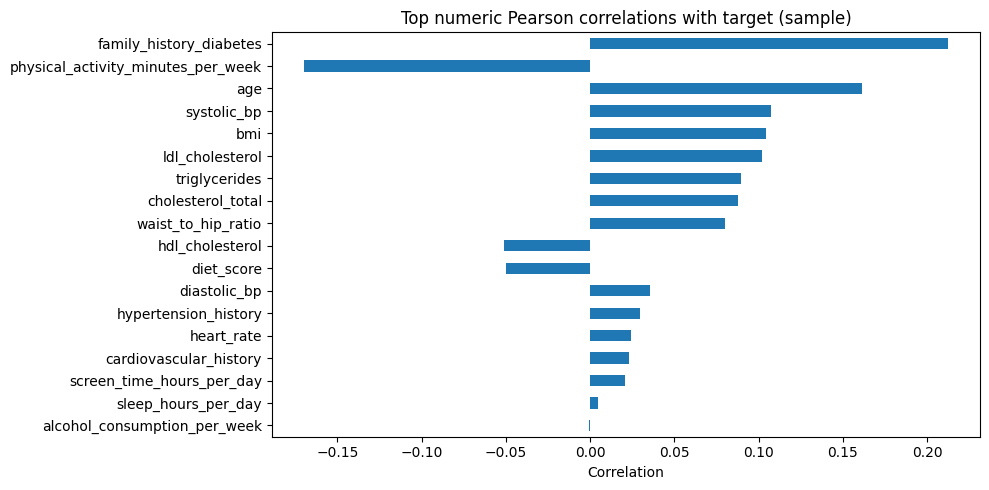

In [7]:
import matplotlib.pyplot as plt

PLOT_SAMPLE = 200_000
eda = train.sample(min(PLOT_SAMPLE, len(train)), random_state=SEED)

# Numeric feature correlation with target (Pearson on sample)
corrs = eda[num_cols + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
display(corrs.head(15))

plt.figure(figsize=(10, 5))
corrs.head(20).iloc[::-1].plot(kind="barh")
plt.title("Top numeric Pearson correlations with target (sample)")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


In [8]:
# Target rate by categorical features
for c in cat_cols:
    tmp = train.groupby(c)[TARGET].mean().sort_values(ascending=False)
    display(tmp.to_frame("target_rate"))


,target_rate
gender,
Other,0.640566
Male,0.624294
Female,0.622205


,target_rate
ethnicity,
Other,0.635936
Asian,0.628493
White,0.624105
Black,0.623879
Hispanic,0.616314


,target_rate
education_level,
No formal,0.636066
Graduate,0.627008
Highschool,0.621462
Postgraduate,0.616647


,target_rate
income_level,
Low,0.630328
Lower-Middle,0.626835
High,0.623593
Upper-Middle,0.620420
Middle,0.620291


,target_rate
smoking_status,
Former,0.625331
Current,0.623124
Never,0.622911


,target_rate
employment_status,
Employed,0.624643
Unemployed,0.622130
Student,0.621586
Retired,0.618058


Top drift numeric features: ['physical_activity_minutes_per_week', 'triglycerides', 'cholesterol_total']


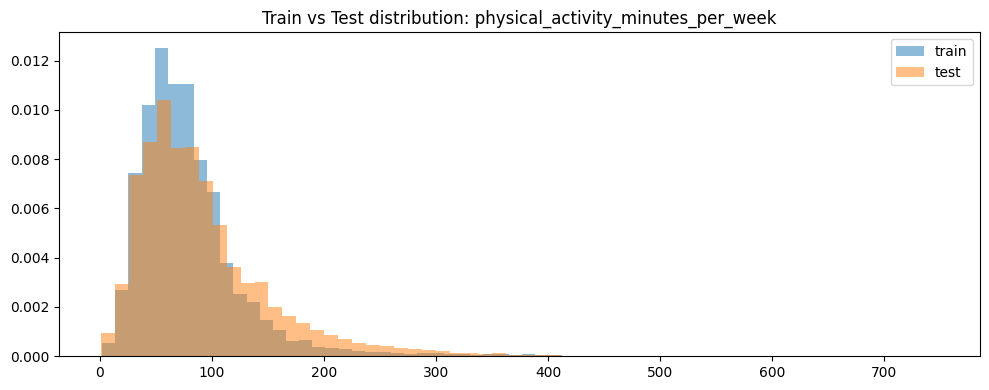

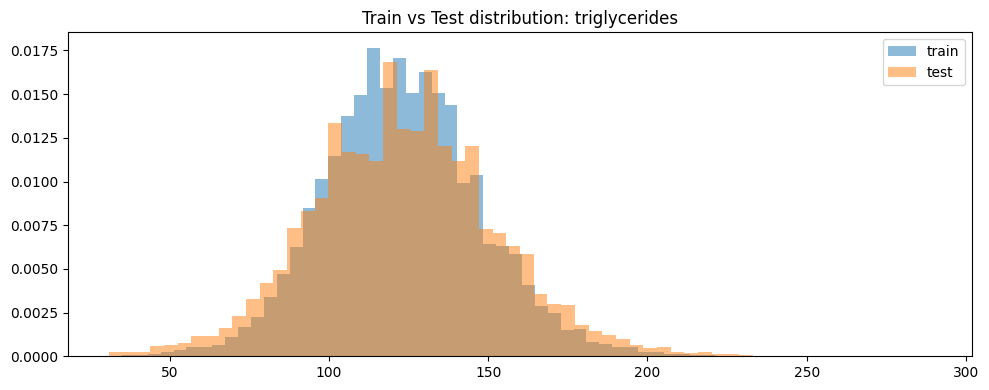

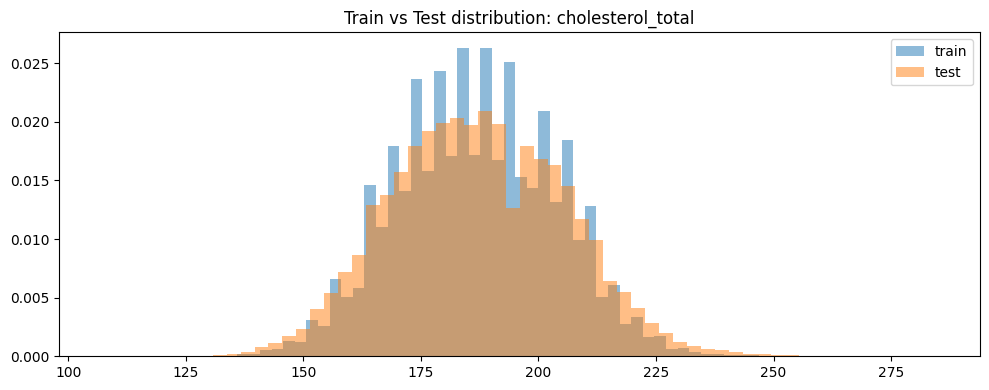

In [9]:
# Quick distribution check for the most drifted numeric feature(s)
top_drift_feats = ks_table.head(3)["feature"].tolist()
print("Top drift numeric features:", top_drift_feats)

plot_train = train.sample(min(PLOT_SAMPLE, len(train)), random_state=SEED)
plot_test  = test.sample(min(PLOT_SAMPLE, len(test)), random_state=SEED)

for f in top_drift_feats:
    plt.figure(figsize=(10, 4))
    plt.hist(plot_train[f], bins=60, alpha=0.5, density=True, label="train")
    plt.hist(plot_test[f],  bins=60, alpha=0.5, density=True, label="test")
    plt.title(f"Train vs Test distribution: {f}")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 5. Feature Engineering

We keep feature engineering **domain-inspired but mechanical**, to avoid overfitting:

- **visceral_fat_index** = BMI × waist-to-hip ratio  
- **map** (mean arterial pressure) = diastolic + (systolic−diastolic)/3  
- **chol_hdl_ratio** = total cholesterol / HDL  
- **pulse_pressure** = systolic − diastolic  
- **lipid_balance** = (LDL − HDL) and triglycerides transforms  
- behavioral interactions (screen/sleep, activity/age)

### Optional: drift-alignment via RankGauss (QuantileTransformer)
RankGauss (normal quantile transform) can reduce train/test distribution mismatch in *some* synthetic datasets.

**Important:** if you fit RankGauss on `train+test`, your CV score can be slightly optimistic (because you used test distribution). It is allowed on Kaggle (unsupervised), but you should be aware of the tradeoff.


In [10]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Clinical ratios
    df["visceral_fat_index"] = df["bmi"] * df["waist_to_hip_ratio"]
    df["map"] = df["diastolic_bp"] + (df["systolic_bp"] - df["diastolic_bp"]) / 3.0
    df["pulse_pressure"] = df["systolic_bp"] - df["diastolic_bp"]

    df["chol_hdl_ratio"] = df["cholesterol_total"] / (df["hdl_cholesterol"] + 1e-6)
    df["ldl_hdl_ratio"] = df["ldl_cholesterol"] / (df["hdl_cholesterol"] + 1e-6)
    df["non_hdl_chol"] = df["cholesterol_total"] - df["hdl_cholesterol"]

    # Skew handling
    df["log_triglycerides"] = np.log1p(df["triglycerides"])

    # Behavior interactions
    df["screen_sleep_ratio"] = df["screen_time_hours_per_day"] / (df["sleep_hours_per_day"] + 1e-6)
    df["activity_per_age"] = df["physical_activity_minutes_per_week"] / (df["age"] + 1e-6)

    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

# Update feature lists after FE
train_features_fe = [c for c in train_fe.columns if c != TARGET]
cat_cols_fe = [c for c in train_features_fe if train_fe[c].dtype == "object"]
num_cols_fe = [c for c in train_features_fe if c not in cat_cols_fe + [ID_COL]]

print("Added engineered features:", sorted(set(train_features_fe) - set(train_features)))
print("Total features:", len(train_features_fe), "| numeric:", len(num_cols_fe), "| categorical:", len(cat_cols_fe))


Added engineered features: ['activity_per_age', 'chol_hdl_ratio', 'ldl_hdl_ratio', 'log_triglycerides', 'map', 'non_hdl_chol', 'pulse_pressure', 'screen_sleep_ratio', 'visceral_fat_index']
Total features: 34 | numeric: 27 | categorical: 6


In [11]:
# Optional RankGauss (QuantileTransformer) fitted on train+test for drift alignment
USE_RANKGAUSS = True
RANKGAUSS_N_QUANTILES = 1000

if USE_RANKGAUSS:
    print("Applying RankGauss (QuantileTransformer) on numeric features using train+test fit...")
    qt = QuantileTransformer(
        n_quantiles=RANKGAUSS_N_QUANTILES,
        output_distribution="normal",
        random_state=SEED,
        subsample=int(1e9)  # use full data
    )
    all_num = pd.concat([train_fe[num_cols_fe], test_fe[num_cols_fe]], axis=0, ignore_index=True)
    all_num_t = qt.fit_transform(all_num)

    train_fe.loc[:, num_cols_fe] = all_num_t[:len(train_fe)]
    test_fe.loc[:, num_cols_fe]  = all_num_t[len(train_fe):]
    del all_num, all_num_t
    gc.collect()
else:
    print("Skipping RankGauss.")


Applying RankGauss (QuantileTransformer) on numeric features using train+test fit...


### Optional: KMeans clusters (patient profiling)

Clusters can act as a compact “phenotype” feature, capturing multi-feature patterns.  
We cluster only on numeric features **after** optional RankGauss (KMeans likes roughly-normal features).


In [12]:
USE_KMEANS = True
N_CLUSTERS = 7

if USE_KMEANS:
    print(f"Fitting KMeans with n_clusters={N_CLUSTERS} ...")
    km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
    train_fe["cluster"] = km.fit_predict(train_fe[num_cols_fe])
    test_fe["cluster"]  = km.predict(test_fe[num_cols_fe])
    # treat as categorical
    cat_cols_model = cat_cols_fe + ["cluster"]
else:
    print("Skipping KMeans clusters.")
    cat_cols_model = cat_cols_fe

display(train_fe[["cluster"]].head() if USE_KMEANS else pd.DataFrame({"cluster": []}))


Fitting KMeans with n_clusters=7 ...


,cluster
0,0
1,1
2,1
3,3
4,3


## 6. Modeling Strategy

We train models using **Stratified K-Fold** and evaluate ROC AUC.

We build an ensemble of:

- **CatBoost** (handles categoricals well; GPU-friendly)
- **XGBoost** (strong on tabular data; GPU-friendly)

LightGBM can also be strong, but GPU support on Kaggle can be inconsistent depending on the environment build.  
This notebook keeps it optional.

### Practical note on encoding
For tree-based models, **label encoding** of categoricals often works fine (splits learn category thresholds).  
CatBoost can consume raw categoricals; however, after RankGauss + KMeans, we keep a simple label encoding step for consistency across models.


In [13]:
# Label-encode categoricals consistently across train/test
def label_encode_fit_transform(train_df: pd.DataFrame, test_df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = train_df.copy()
    test_df  = test_df.copy()
    for c in cols:
        le = LabelEncoder()
        combined = pd.concat([train_df[c], test_df[c]], axis=0).astype(str)
        le.fit(combined)
        train_df[c] = le.transform(train_df[c].astype(str))
        test_df[c]  = le.transform(test_df[c].astype(str))
    return train_df, test_df

train_m, test_m = label_encode_fit_transform(train_fe, test_fe, cat_cols_model)

X = train_m.drop(columns=[TARGET])
y = train_m[TARGET].astype(int)
X_test = test_m.copy()

print("Model matrix shapes:", X.shape, X_test.shape)


Model matrix shapes: (700000, 35) (300000, 35)


In [14]:
# Downcast numerics to reduce memory (important for big folds)
def downcast_float_int(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in df.columns:
        if c == TARGET:
            continue
        if pd.api.types.is_float_dtype(df[c]):
            df[c] = pd.to_numeric(df[c], downcast="float")
        elif pd.api.types.is_integer_dtype(df[c]):
            df[c] = pd.to_numeric(df[c], downcast="integer")
    return df

X = downcast_float_int(X)
X_test = downcast_float_int(X_test)
gc.collect()

print("Dtypes after downcast:")
display(X.dtypes.value_counts())


Dtypes after downcast:


float32    27
int8        7
int32       1
Name: count, dtype: int64

## 7. Cross-Validation Training (GPU-aware)

We auto-select GPU options when available.


In [15]:
# ---- Models ----
import xgboost as xgb
from catboost import CatBoostClassifier

CONFIG = dict(
    n_folds=5,
    seed=SEED,
    verbose_eval=200,
    early_stopping_rounds=200,
)

kf = StratifiedKFold(n_splits=CONFIG["n_folds"], shuffle=True, random_state=CONFIG["seed"])

oof = np.zeros(len(X), dtype=np.float32)
pred_test = np.zeros(len(X_test), dtype=np.float32)

fold_scores = []

# XGBoost params (GPU if available)
xgb_params = dict(
    n_estimators=8000,
    learning_rate=0.02,
    max_depth=8,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_lambda=1.0,
    min_child_weight=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=CONFIG["seed"],
    n_jobs=-1,
    tree_method="gpu_hist" if HAS_GPU else "hist",
)

# CatBoost params (GPU if available)
cb_params = dict(
    iterations=8000,
    learning_rate=0.03,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=CONFIG["seed"],
    verbose=False,
    task_type="GPU" if HAS_GPU else "CPU",
)

print("XGB tree_method:", xgb_params["tree_method"])
print("CatBoost task_type:", cb_params["task_type"])


XGB tree_method: gpu_hist
CatBoost task_type: GPU


In [16]:
# ---- Optional LightGBM (can be strong; GPU availability depends on Kaggle image) ----
import lightgbm as lgb

USE_LIGHTGBM = True  # set False if you want faster / simpler runs

lgb_params = dict(
    n_estimators=12000,
    learning_rate=0.02,
    num_leaves=64,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="binary",
    random_state=CONFIG["seed"],
    n_jobs=-1,
    device="gpu" if HAS_GPU else "cpu",  # will fallback to CPU automatically if GPU build is missing
    verbose=-1,
)

print("LightGBM device:", lgb_params["device"], "| USE_LIGHTGBM:", USE_LIGHTGBM)


LightGBM device: gpu | USE_LIGHTGBM: True


In [17]:
# ---- Training loop ----
for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y), 1):
    X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
    X_va, y_va = X.iloc[va_idx], y.iloc[va_idx]

    # --- XGBoost ---
    xgb_model = xgb.XGBClassifier(**xgb_params)
    xgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False,
        early_stopping_rounds=CONFIG["early_stopping_rounds"],
    )
    p_xgb_va = xgb_model.predict_proba(X_va)[:, 1]
    p_xgb_te = xgb_model.predict_proba(X_test)[:, 1]

    # --- CatBoost ---
    cb_model = CatBoostClassifier(**cb_params)
    cb_model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va),
        use_best_model=True,
        early_stopping_rounds=CONFIG["early_stopping_rounds"],
    )
    p_cb_va = cb_model.predict_proba(X_va)[:, 1]
    p_cb_te = cb_model.predict_proba(X_test)[:, 1]

    p_models_va = [p_xgb_va, p_cb_va]
    p_models_te = [p_xgb_te, p_cb_te]

    # --- LightGBM (optional; try GPU then fallback to CPU) ---
    lgb_model = None
    if USE_LIGHTGBM:
        try:
            lgb_model = lgb.LGBMClassifier(**lgb_params)
            lgb_model.fit(
                X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                eval_metric="auc",
                callbacks=[lgb.early_stopping(CONFIG["early_stopping_rounds"], verbose=False)],
            )
        except Exception as e:
            if lgb_params.get("device") == "gpu":
                print(f"Fold {fold:02d} LightGBM GPU failed; retrying CPU. Reason: {e}")
                lgb_model = lgb.LGBMClassifier(**{**lgb_params, "device": "cpu"})
                lgb_model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_va, y_va)],
                    eval_metric="auc",
                    callbacks=[lgb.early_stopping(CONFIG["early_stopping_rounds"], verbose=False)],
                )
            else:
                raise

        p_lgb_va = lgb_model.predict_proba(X_va)[:, 1]
        p_lgb_te = lgb_model.predict_proba(X_test)[:, 1]
        p_models_va.append(p_lgb_va)
        p_models_te.append(p_lgb_te)

    # Average ensemble (2 or 3 models)
    p_va = np.mean(p_models_va, axis=0)
    p_te = np.mean(p_models_te, axis=0)

    oof[va_idx] = p_va
    pred_test += p_te / CONFIG["n_folds"]

    fold_auc = roc_auc_score(y_va, p_va)
    fold_scores.append(fold_auc)

    xgb_best = getattr(xgb_model, "best_iteration", None)
    print(f"Fold {fold:02d} AUC: {fold_auc:.6f} | xgb_best_iter={xgb_best} | models={len(p_models_va)}")

    # Clean up
    del X_tr, y_tr, X_va, y_va, xgb_model, cb_model, lgb_model
    gc.collect()

cv_auc = roc_auc_score(y, oof)
print("\nCV AUC (OOF):", f"{cv_auc:.6f}")
print("Fold AUCs:", [round(s, 6) for s in fold_scores])


Default metric period is 5 because AUC is/are not implemented for GPU
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Fold 01 AUC: 0.727103 | xgb_best_iter=1128 | models=3


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 02 AUC: 0.725490 | xgb_best_iter=1407 | models=3


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 03 AUC: 0.726290 | xgb_best_iter=1677 | models=3


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 04 AUC: 0.727633 | xgb_best_iter=1509 | models=3


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 05 AUC: 0.726872 | xgb_best_iter=1688 | models=3

CV AUC (OOF): 0.726673
Fold AUCs: [0.727103, 0.72549, 0.72629, 0.727633, 0.726872]


### 7.1 Inspect Model Behavior (optional)

Feature importance can be informative, but remember: importance ≠ causality.


Default metric period is 5 because AUC is/are not implemented for GPU


,catboost_importance
family_history_diabetes,13.138349
physical_activity_minutes_per_week,12.717818
activity_per_age,5.762672
age,5.682455
triglycerides,3.969484
diet_score,3.925087
heart_rate,3.630625
id,3.572057
screen_time_hours_per_day,3.012214
cholesterol_total,2.961373


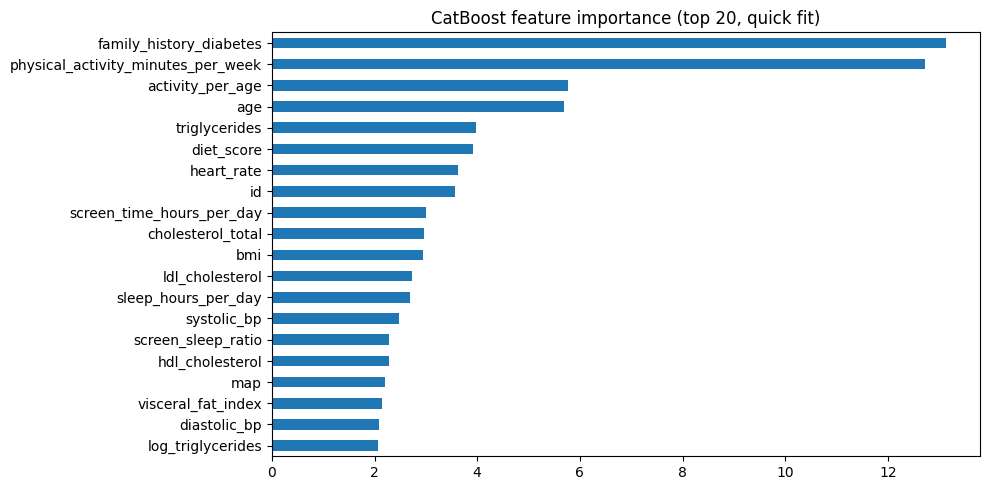

In [18]:
# CatBoost feature importance on a subsample (fast)
try:
    sample_idx = np.random.RandomState(SEED).choice(len(X), size=200_000, replace=False)
    X_s = X.iloc[sample_idx]
    y_s = y.iloc[sample_idx]

    cb_quick = CatBoostClassifier(**{**cb_params, "iterations": 2000})
    cb_quick.fit(X_s, y_s, verbose=False)

    importances = pd.Series(cb_quick.get_feature_importance(), index=X.columns).sort_values(ascending=False)
    display(importances.head(20).to_frame("catboost_importance"))

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 5))
    importances.head(20).iloc[::-1].plot(kind="barh")
    plt.title("CatBoost feature importance (top 20, quick fit)")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Importance step skipped due to:", repr(e))


## 8. Create Submission

The submission file must contain:

- `id`
- `diagnosed_diabetes` (predicted probability)

We also apply basic sanity checks to keep predictions within [0, 1].


In [19]:
submission = sub.copy()
submission[TARGET] = np.clip(pred_test, 0, 1)

assert submission.shape[0] == len(test), "Submission rows must match test rows."
assert submission[ID_COL].equals(test[ID_COL]), "Submission ids must align with test ids."

out_path = "submission.csv"
submission.to_csv(out_path, index=False)
print("Saved:", out_path)
display(submission.head())


Saved: submission.csv


,id,diagnosed_diabetes
0,700000,0.516627
1,700001,0.706565
2,700002,0.766101
3,700003,0.396929
4,700004,0.904088


## 9. Next Steps (if you want to push score)

- Increase folds to 10 (slower but sometimes more stable)
- Tune XGBoost + CatBoost hyperparameters (e.g., depth, L2, subsample)
- Replace label encoding with proper categorical handling per model:
  - CatBoost: pass raw categoricals and `cat_features`
  - XGBoost: one-hot (sparse) or native categorical splits (experimental)
- Build a drift-aware validation (train↔test domain splits) if drift is significant
